<a href="https://colab.research.google.com/github/AkankshaB123/Optimisation/blob/main/GradientBoosting_v1(Session4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#=============================================================
# Gradient Boosting Algorithm
#=============================================================

# Problem Statement
#### Using the Boston Housing Data, predict the prices using Gradient Boosting (XGBoost)

In [4]:
#Preparing the Environment

import pandas as pd
import numpy as np # numpy is required for hstack
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Load the Boston Housing dataset from the original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-504092788.py:11: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [5]:
#Loading the Data
# Feature names from the original Boston dataset documentation
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Create a DataFrame from the loaded data and target
boston_df = pd.DataFrame(data, columns=feature_names)
boston_df['PRICE'] = target # Add the target variable as a column

print("First 5 rows of the dataset:")
print(boston_df.head())
print("\nShape of the dataset:", boston_df.shape)
print("\nDataset Information:")
boston_df.info()

First 5 rows of the dataset:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

Shape of the dataset: (506, 14)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS

PTRATIO: Pupil-Teacher Ratio is inversely proportional to price



*   CRIM: crime level in the area
*   ZN: how much land is for big houses
*   INDUS: how industrial the area is
*   CHAS: whether the area is next to the river
*   NOX: air pollution level
*   RM: average number of rooms in a house  
*   AGE: how old the houses are
*   DIS: how far the area is from job centers   
*   RAD: how easy it is to get to highways
*   TAX: property tax level
*   PTRATIO: number of students per teacher
*   B: measure related to racial makeup of the area
*   B: 1000(8k - 0.63)^2 where 8k is the proportion of blocks by town
*   LSTAT: percentage(%) of lower income residents

Target value

MEDV: typical house price in the area (in thousands)

# Exploratory Data Analysis

In [6]:
data = pd.DataFrame(boston_df)
data.columns = boston_df.columns
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [7]:
# data['PRICE'] = boston_df.target #Dependent variable
data.info()
stats_df = pd.DataFrame(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


### Separate the target variable and rest of the variables using .iloc to subset/divide it

In [8]:
X, y = data.iloc[:,:-1],data.iloc[:,-1]

### XGBoost supports and gives it acclaimed performance and efficiency gains

In [9]:
data_dmatrix = xgb.DMatrix(data=X,label=y)

# =============================================================================
# Hyper Parameters in XGBoost
* learning_rate: step size shrinkage used to prevent overfitting. Range is [0,1]
* max_depth: determines how deeply each tree is allowed to grow during any boosting round.
* subsample: percentage of samples used per tree. Low value can lead to underfitting.
* colsample_bytree: percentage of features used per tree. High value can lead to overfitting.
* n_estimators: number of trees you want to build.
* objective: determines the loss function to be used like reg:linear for regression problem
* reg:logistic for classification problems with only decision, binary:logistic for classification problems with probability
# =============================================================================

## Hyperparameters + Regularization Parameters (To solve for overfitting given boosting is prone to overfitting)

#########################################################################
### Regularization Parameters
* gamma: controls whether a given node will split based on the expected reduction in loss after the split. A higher value leads to fewer splits. Supported only for tree-based learners.
* alpha: L1 regularization on leaf weights. A large value leads to more regularization.
* lambda: L2 regularization on leaf weights and is smoother than L1 regularization.
#########################################################################

In [29]:
#Splitting the Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [30]:
#Fitting the XGBoost Model
xg_reg = xgb.XGBRegressor(objective='reg:linear', colsample_bytree = 0.3, learning_rate = 0.1,
                          max_depth=20, alpha = 20, n_estimators=10000)

In [31]:
xg_reg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:01:22] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(alpha=20, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, ...)

By changing n_estimators, RMSE (decrease) by

In [32]:
#Train Error
preds_train = xg_reg.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
print("TRAIN RMSE: %f" % (rmse_train))

TRAIN RMSE: 1.578938


In [33]:
#Test Error
preds = xg_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("TEST RMSE: %f" % (rmse))

TEST RMSE: 4.002968


* RMSE (Root Mean Squared Error): Standard Deviation of the residuals (Errors)
* Higher the RMSE, worse is the model
* Lower the RMSE, **better** is the model

### Model tuning
Two things(influencing factors) related to RMSE:
1. max_depth from 5/10 to 20 (RMSE decrease)
2. n_estimators (sequential models) from 10 to 1000 (RMSE decline) - *typical values: 400-1500 Models(depending on size of data)*
3. alpha - regularization parameter
4. Learning Rate - from 0.1 to 0.01
* Tune parameters to influence RMSE

Grid Search, Random Search

In context of model, Train error is low, but Test is high: Still overfitting
* either alpha or lamda (regularization params) - solves overfitting

# =============================================================================
# Cross Validation:
* num_boost_round: denotes the number of trees you build (analogous to n_estimators)
* metrics: tells the evaluation metrics to be watched during CV
* as_pandas: to return the results in a pandas DataFrame.
* early_stopping_rounds: finishes training of the model early if the hold-out metric ("rmse" in our case) does not improve for a given number of rounds.
* seed: for reproducibility of results.
# =============================================================================

In [34]:
#k-fold Cross Validation using XGBoost
params = {"objective":"reg:linear",'colsample_bytree': 0.3,'learning_rate': 0.01,
                'max_depth': 5, 'alpha': 10}# Parameter Dictionary

In [35]:
cv_results = xgb.cv(dtrain=data_dmatrix, params=params, nfold=3,
                    num_boost_round=2000,early_stopping_rounds=10,metrics="rmse", as_pandas=True, seed=123)

cv_results.head()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:225: UserWarning: [08:01:34] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  return getattr(self.bst, name)(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:231: UserWarning: [08:01:34] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  self.bst.update(self.dtrain, iteration, fobj)


,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,9.134429,0.181423,9.143492,0.373826
1,9.099583,0.180446,9.118573,0.372817
2,9.056199,0.180508,9.087007,0.372605
3,9.017587,0.179568,9.057800,0.371040
4,8.984147,0.174451,9.034256,0.370367


In [36]:
print((cv_results["test-rmse-mean"]).tail(1))

xg_reg = xgb.train(params=params, dtrain=data_dmatrix, num_boost_round=2000)

1999    3.454987
Name: test-rmse-mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:01:41] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


# =========================================================
# Final Model
# =========================================================

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


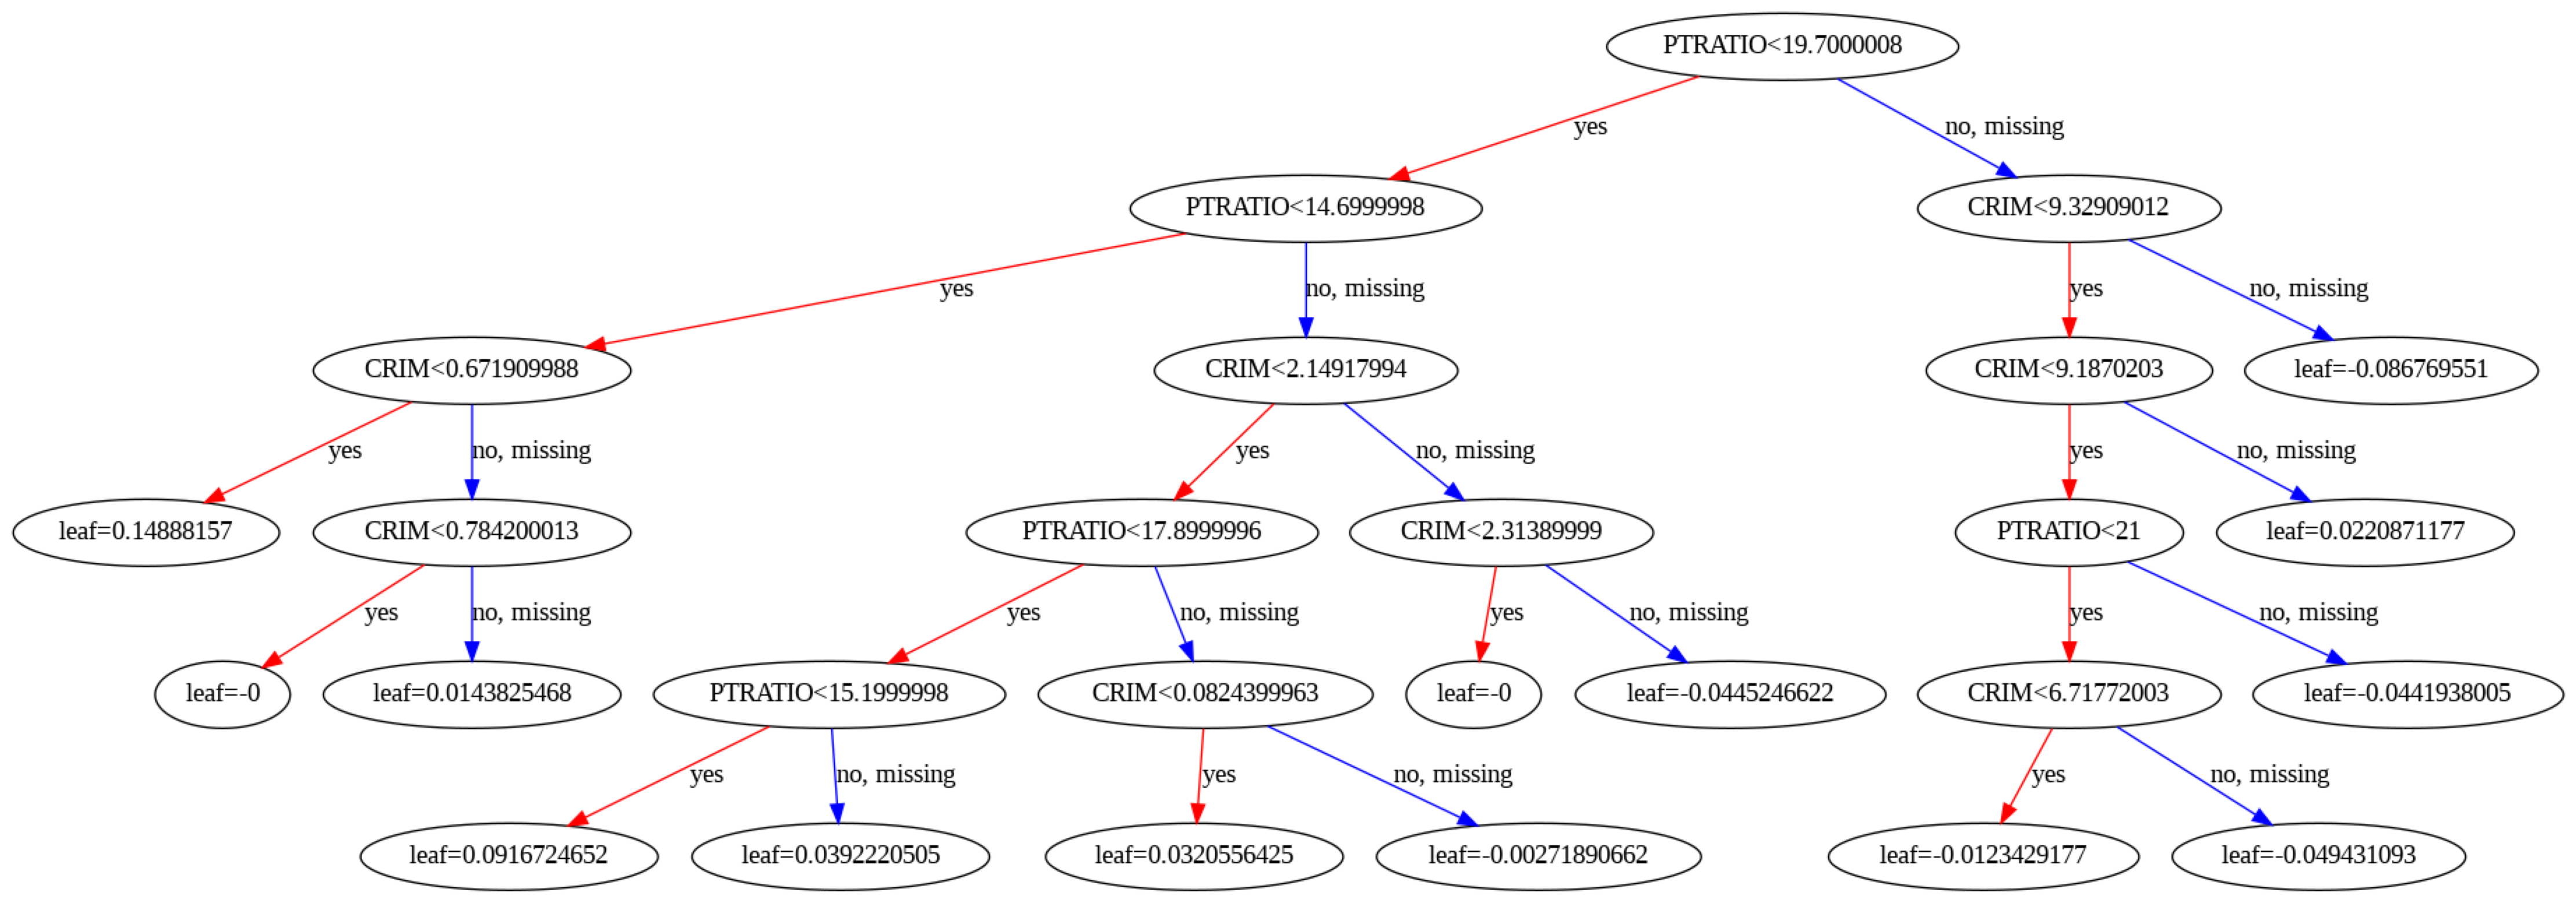

In [37]:
import matplotlib.pyplot as plt
xgb.plot_tree(xg_reg, num_trees=15)
plt.rcParams['figure.figsize']=('100','20')
plt.show()

# ==============================================================
# Feature Importance
# ==============================================================

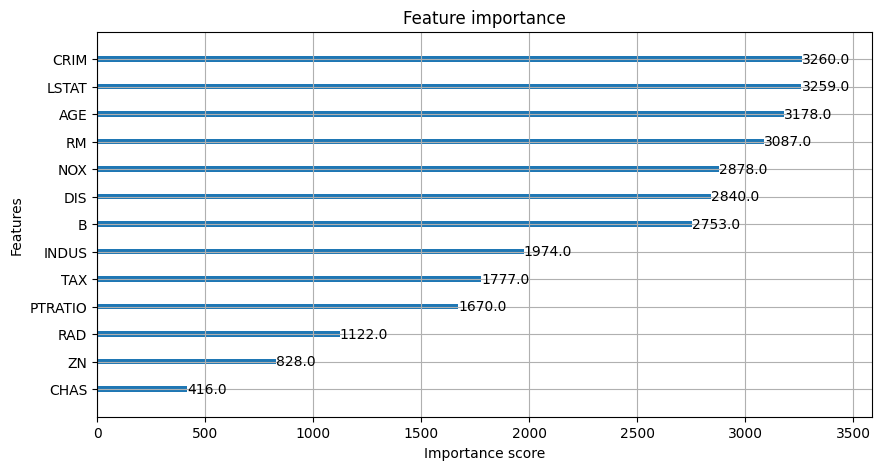

In [40]:
xgb.plot_importance(xg_reg)
plt.rcParams['figure.figsize'] = [12, 10]
plt.show()